In [46]:
1+1

2

In [47]:
# Add parent folder (project root) to sys.path so notebook can import modules
import sys
from pathlib import Path
project_root = Path.cwd().parent.resolve()
if str(project_root / 'HPFC') not in sys.path:
    sys.path.insert(0, str(project_root / 'HPFC'))
print('Added to sys.path:', str(project_root / 'HPFC'))

Added to sys.path: E:\HPC\PFC-test\26140\HPFC


In [48]:
# numeric math
import math

# array numerics
import numpy as np  # for CPU
import cupy as cp   # for CUDA GPU

# PFC
import PFC2D_model, PFC2D_geometry, PFC2D_kernels
import sHPFC

# interactive plotting
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "png" # Set default renderer to PNG for static images in notebooks

In [49]:
def GetDensityHeatmap(psi, X, Y):
  print(psi.min(), psi.max(), psi.mean())

  fig = go.Figure()
  fig.add_trace(go.Heatmap(z=psi, x=X[0,:], y=Y[:,0], colorscale='haline', showscale=False))
  # make axis use same scale, keep it square
  fig.update_xaxes(scaleanchor = "y", scaleratio = 1)

  # hide axis labels
  fig.update_xaxes(
    showticklabels=False,
    showgrid=False,
    zeroline=False
  )
  fig.update_yaxes(
    showticklabels=False,
    showgrid=False,
    zeroline=False
  )

  # zero margins
  fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))

  # figure size 100x100
  fig.update_layout(
    width=1200,
    height=1200*Y.max()/X.max()
  )

  return fig

In [50]:
# Geometry
q1 = np.array([-3**0.5/2,-0.5])
q2 = np.array([3**0.5/2,-0.5])
q3 = np.array([0,1])
a = 4*np.pi/3**0.5
h = 4*np.pi
psi0 = -0.265
A0 = 0.3162

Mx = 200
My = 111

Nx = 1600
Ny = 1600
Lx = a*Mx
Ly = h*My

X, Y = np.meshgrid(np.linspace(0,Lx,Nx,endpoint=False),np.linspace(0,Ly,Ny,endpoint=False))
dx = X[0,1]
dy = Y[1,0]

In [51]:
# Initial state (dislocation pair)
ba1 = +np.array([a, 0]) # shifts lattice one full atom to the right above the point ra1
ba2 = -np.array([a, 0]) # shifts lattice one full atom to the left above the point ra2

ra1 = np.array([a*80.0, h*55.0])  # originated at a peak
ra2 = np.array([a*120.0, h*55.0])

s1_1 = (q1[0]*ba1[0] + q1[1]*ba1[1])*0.5/np.pi
s2_1 = (q2[0]*ba1[0] + q2[1]*ba1[1])*0.5/np.pi
s3_1 = (q3[0]*ba1[0] + q3[1]*ba1[1])*0.5/np.pi
s1_2 = (q1[0]*ba2[0] + q1[1]*ba2[1])*0.5/np.pi
s2_2 = (q2[0]*ba2[0] + q2[1]*ba2[1])*0.5/np.pi
s3_2 = (q3[0]*ba2[0] + q3[1]*ba2[1])*0.5/np.pi

A1 = A0 * np.exp(-1.j * (s1_1 * np.arctan2(X - ra1[0], Y - ra1[1]) + s1_2 * np.arctan2(X - ra2[0], Y - ra2[1])))
A2 = A0 * np.exp(-1.j * (s2_1 * np.arctan2(X - ra1[0], Y - ra1[1]) + s2_2 * np.arctan2(X - ra2[0], Y - ra2[1])))
A3 = A0 * np.exp(-1.j * (s3_1 * np.arctan2(X - ra1[0], Y - ra1[1]) + s3_2 * np.arctan2(X - ra2[0], Y - ra2[1])))

psi = (
    psi0 +
    A1 * np.exp(1.j * (q1[0]*X + q1[1]*Y)) + A1.conj() * np.exp(-1.j * (q1[0]*X + q1[1]*Y)) +
    A2 * np.exp(1.j * (q2[0]*X + q2[1]*Y)) + A2.conj() * np.exp(-1.j * (q2[0]*X + q2[1]*Y)) +
    A3 * np.exp(1.j * (q3[0]*X + q3[1]*Y)) + A3.conj() * np.exp(-1.j * (q3[0]*X + q3[1]*Y))
).real

In [52]:
x1 = int(a*(80-6)//dx)
x2 = int(a*(120+6)//dx)
y1 = int((h*55 - ((x2-x1)*dx)//2)//dy)
y2 = int((h*55 + ((x2-x1)*dx)//2)//dy)
x1, x2, y1, y2

(591, 1008, 575, 1009)

-1.2135719429095606 1.6320177459263574 -0.2640514902076742


Resorting to unclean kill browser.


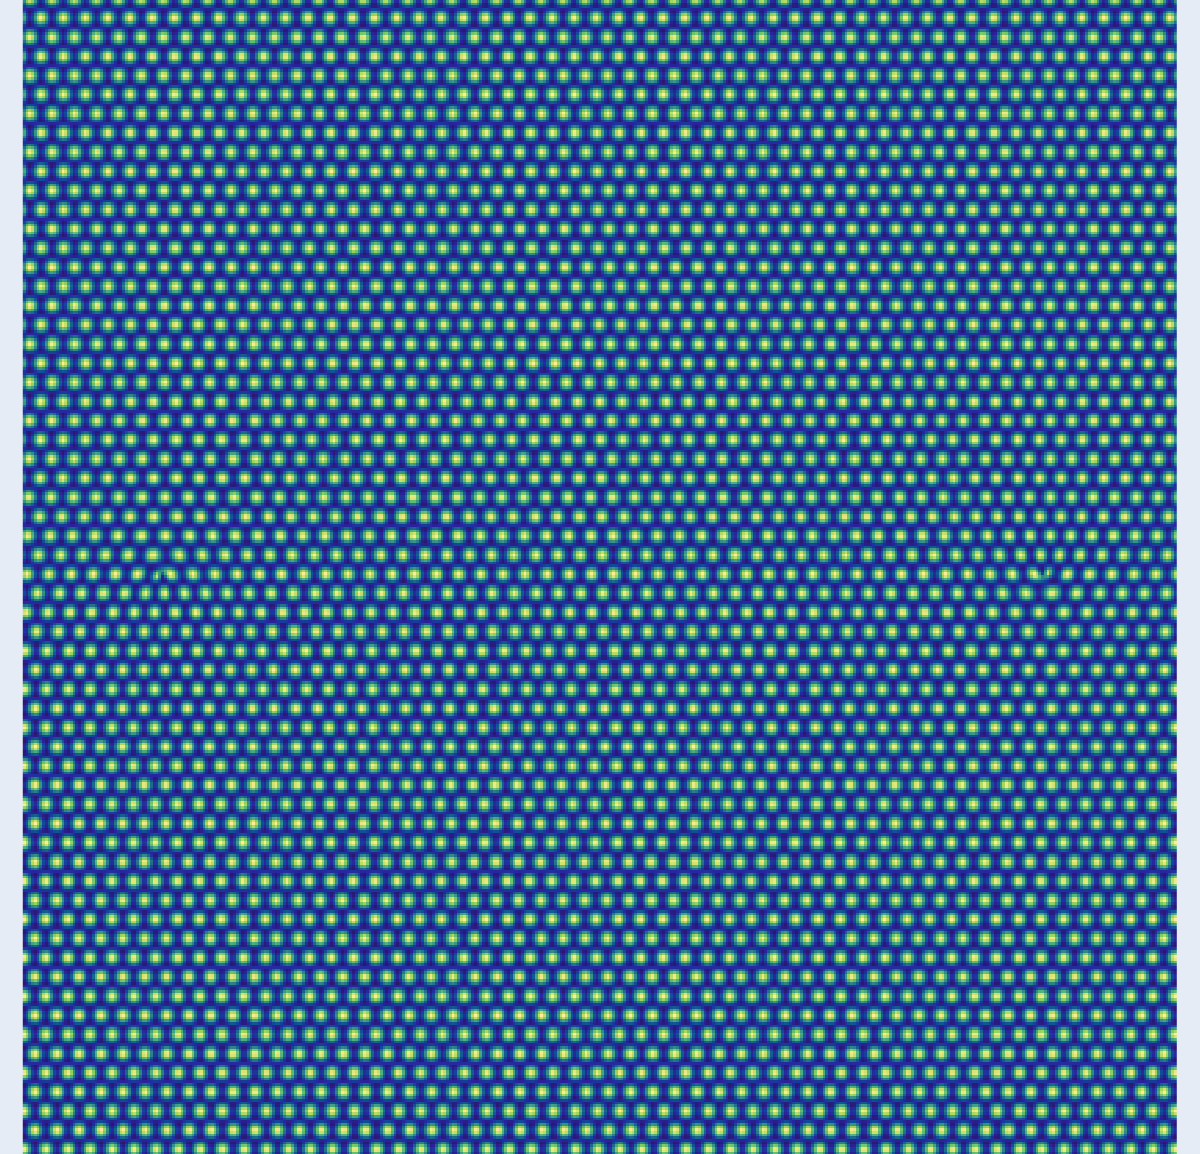

In [53]:
GetDensityHeatmap(psi[y1:y2, x1:x2], X[y1:y2, x1:x2], Y[y1:y2, x1:x2]).show()

In [54]:
model = PFC2D_model.model_2D(temp=-0.2, beta=1.0, Gamma = 1.0, rho0 = 2.**(-6), Gamma_s = 2.**(-6), dt=0.1)
geometry = PFC2D_geometry.geometry_2D((Nx, Ny), Lx, Ly)
sim = sHPFC.sHPFC(psi0 = psi, model = model, geometry = geometry)

In [55]:
force_t = np.zeros((40, *psi.shape), dtype=np.float64)
psi_t = np.zeros((40, *psi.shape), dtype=np.float64)
for i in range(40):
    sim.Timestep_sHPFC()
    force_x_w_temp = sim._payload_mgr.real(sim._payload_mgr.ifftn(
      sim.kernel_gaussian * sim.force_x_hat
    )).get()
    force_y_w_temp = sim._payload_mgr.real(sim._payload_mgr.ifftn(
      sim.kernel_gaussian * sim.force_y_hat
    )).get()
    force_t[i,:,:] = ((force_x_w_temp**2 + force_y_w_temp**2)**0.5)
    psi_t[i,:,:] = sim.psi.get()

In [56]:
force_crop = force_t[:, y1:y2, x1:x2]
psi_crop = psi_t[:, y1:y2, x1:x2]
X_crop = X[y1:y2, x1:x2]
Y_crop = Y[y1:y2, x1:x2]

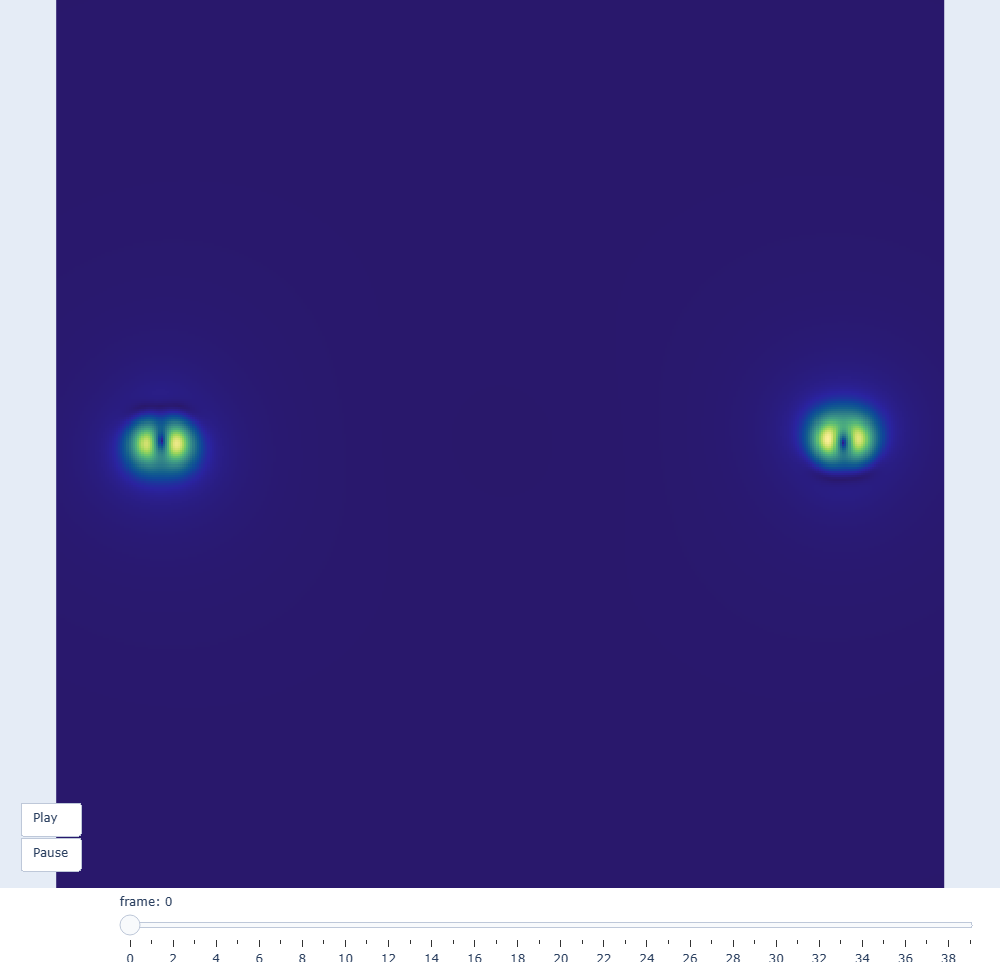

In [57]:
frames = [
    go.Frame(
        data=[go.Heatmap(
            z=force_crop[i],
            x=X_crop[0, :],
            y=Y_crop[:, 0],
            colorscale='haline',
            showscale=False,
        )],
        name=str(i)
    )
    for i in range(force_crop.shape[0])
]

fig = go.Figure(
    data=[go.Heatmap(
        z=force_crop[0],
        x=X_crop[0, :],
        y=Y_crop[:, 0],
        colorscale='haline',
        showscale=False,
    )],
    frames=frames

)

fig.update_xaxes(scaleanchor='y', scaleratio=1)
fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_layout(
    margin=dict(l=0, r=0, t=0, b=0),
    width=1000,
    height=1000 * Y_crop.max() / X_crop.max(),
    updatemenus=[{
        'type': 'buttons',
        'showactive': False,
        'x': 0.02,
        'y': 0.02,
        'xanchor': 'left',
        'yanchor': 'bottom',
        'buttons': [
            {'label': 'Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 120, 'redraw': True}, 'fromcurrent': True}]},
            {'label': 'Pause', 'method': 'animate', 'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]}
        ]
    }],
    sliders=[{
        'x': 0.12,
        'y': 0.02,
        'len': 0.86,
        'currentvalue': {'prefix': 'frame: '},
        'steps': [
            {'args': [[str(i)], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}], 'label': str(i), 'method': 'animate'}
            for i in range(force_crop.shape[0])
        ]
    }]

)

fig.show()

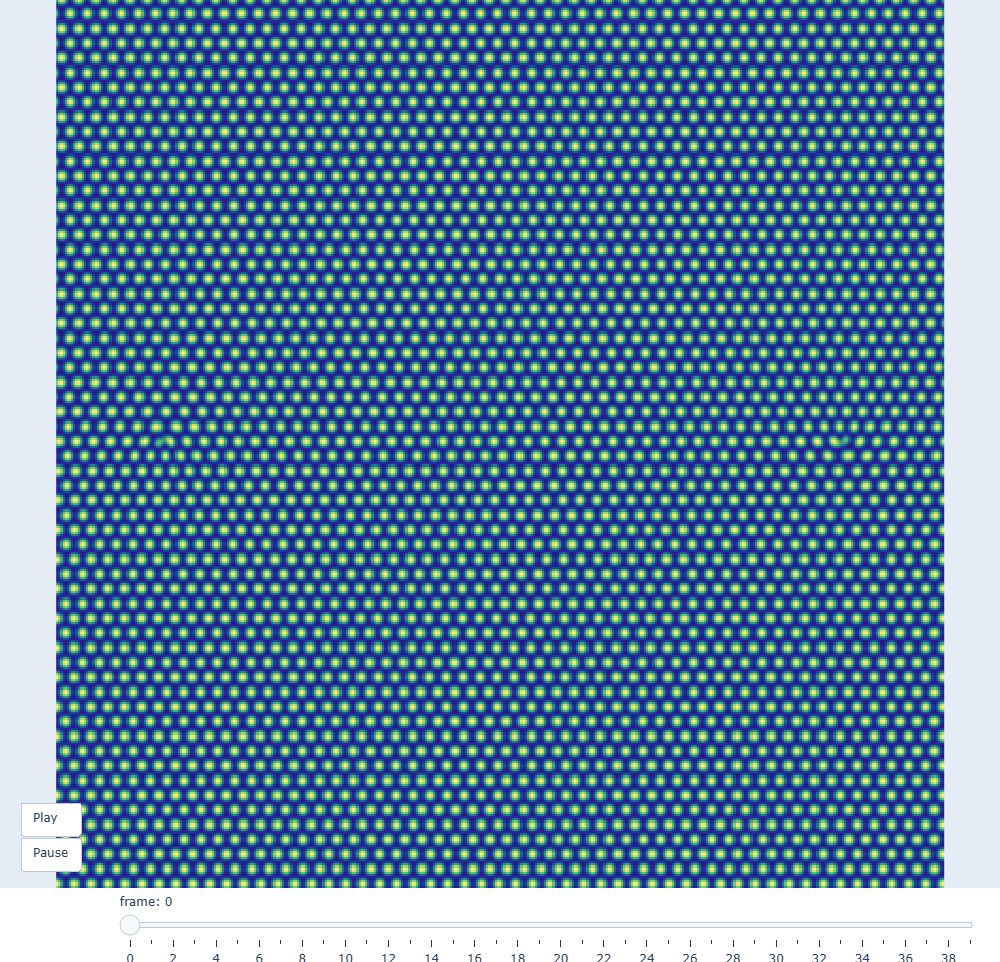

In [58]:
frames = [
    go.Frame(
        data=[go.Heatmap(
            z=psi_crop[i],
            x=X_crop[0, :],
            y=Y_crop[:, 0],
            colorscale='haline',
            showscale=False,
        )],
        name=str(i)
    )
    for i in range(psi_crop.shape[0])
]

fig = go.Figure(
    data=[go.Heatmap(
        z=psi_crop[0],
        x=X_crop[0, :],
        y=Y_crop[:, 0],
        colorscale='haline',
        showscale=False,
    )],
    frames=frames

)

fig.update_xaxes(scaleanchor='y', scaleratio=1)
fig.update_xaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_yaxes(showticklabels=False, showgrid=False, zeroline=False)
fig.update_layout(
    margin=dict(l=0, r=0, t=0, b=0),
    width=1000,
    height=1000 * Y_crop.max() / X_crop.max(),
    updatemenus=[{
        'type': 'buttons',
        'showactive': False,
        'x': 0.02,
        'y': 0.02,
        'xanchor': 'left',
        'yanchor': 'bottom',
        'buttons': [
            {'label': 'Play', 'method': 'animate', 'args': [None, {'frame': {'duration': 120, 'redraw': True}, 'fromcurrent': True}]},
            {'label': 'Pause', 'method': 'animate', 'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate'}]}
        ]
    }],
    sliders=[{
        'x': 0.12,
        'y': 0.02,
        'len': 0.86,
        'currentvalue': {'prefix': 'frame: '},
        'steps': [
            {'args': [[str(i)], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}], 'label': str(i), 'method': 'animate'}
            for i in range(psi_crop.shape[0])
        ]
    }]

)

fig.show()